In [15]:
import pandas as pd
import sqlite3

In [16]:
conn = sqlite3.connect("../data/processed/activities.db")
df = pd.read_sql_query("SELECT * FROM activities", conn)

print(df.head())
print(df.info())

            id                  name               type           start_time  \
0  10185345906  Sławoborze Chodzenie            walking  2022-12-25T17:50:02   
1  10195494905                  Siła  strength_training  2022-12-27T16:34:27   
2  10200684937   Ergometr wioślarski      indoor_rowing  2022-12-28T16:09:50   
3  10201041796   Ergometr wioślarski      indoor_rowing  2022-12-28T16:26:24   
4  10201541415    Szczecin Chodzenie            walking  2022-12-28T18:30:06   

   duration_sec  distance_km  avg_speed  max_speed  avg_hr  max_hr  \
0   1062.738037      1.19291     0.1122     0.1773    92.0   110.0   
1   3712.457000      0.00000     0.0000        NaN   136.0   177.0   
2    619.109009      0.00000     0.0000        NaN   138.0   162.0   
3   2661.094971      0.00000     0.0000        NaN   155.0   184.0   
4   1038.072021      1.18925     0.1146     0.3630   120.0   135.0   

   training_load  hr_zone_0  hr_zone_1  hr_zone_2  hr_zone_3  hr_zone_4  \
0            NaN       

In [17]:
df["start_time"] = pd.to_datetime(df["start_time"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 982 entries, 0 to 981
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             982 non-null    int64         
 1   name           982 non-null    str           
 2   type           982 non-null    str           
 3   start_time     982 non-null    datetime64[us]
 4   duration_sec   982 non-null    float64       
 5   distance_km    982 non-null    float64       
 6   avg_speed      972 non-null    float64       
 7   max_speed      526 non-null    float64       
 8   avg_hr         982 non-null    float64       
 9   max_hr         982 non-null    float64       
 10  training_load  266 non-null    float64       
 11  hr_zone_0      266 non-null    float64       
 12  hr_zone_1      266 non-null    float64       
 13  hr_zone_2      266 non-null    float64       
 14  hr_zone_3      266 non-null    float64       
 15  hr_zone_4      266 non-null    flo

In [18]:
df_indexed = df.set_index("start_time")
monthly = df_indexed["training_load"].resample("ME").sum()
print(monthly)

start_time
2022-12-31       0.000000
2023-01-31       0.000000
2023-02-28       0.000000
2023-03-31       0.000000
2023-04-30       0.000000
2023-05-31       0.000000
2023-06-30       0.000000
2023-07-31       0.000000
2023-08-31       0.000000
2023-09-30       0.000000
2023-10-31       0.000000
2023-11-30       0.000000
2023-12-31       0.000000
2024-01-31       0.000000
2024-02-29       0.000000
2024-03-31       0.000000
2024-04-30       0.000000
2024-05-31       0.000000
2024-06-30       0.000000
2024-07-31       0.000000
2024-08-31       0.000000
2024-09-30       0.000000
2024-10-31       0.000000
2024-11-30       0.000000
2024-12-31       0.000000
2025-01-31       0.000000
2025-02-28       0.000000
2025-03-31       0.000000
2025-04-30       0.000000
2025-05-31       0.000000
2025-06-30       0.000000
2025-07-31       0.000000
2025-08-31       0.000000
2025-09-30       0.000000
2025-10-31       0.000000
2025-11-30     322.327179
2025-12-31     977.732620
2026-01-31     753.901306
2

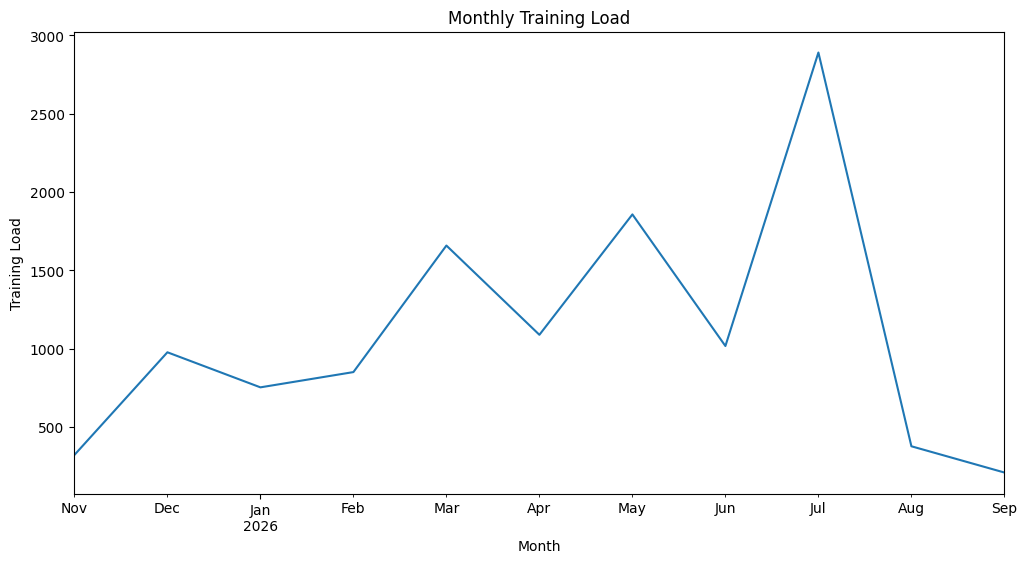

In [19]:
import matplotlib.pyplot as plt

monthly_filtered = monthly[monthly.index >= "2025-11-01"]
monthly_filtered.plot(kind="line", title="Monthly Training Load", figsize=(12, 6))
plt.xlabel("Month")
plt.ylabel("Training Load")
plt.savefig("../visuals/monthly_training_load.png", dpi=150, bbox_inches="tight")
plt.show()

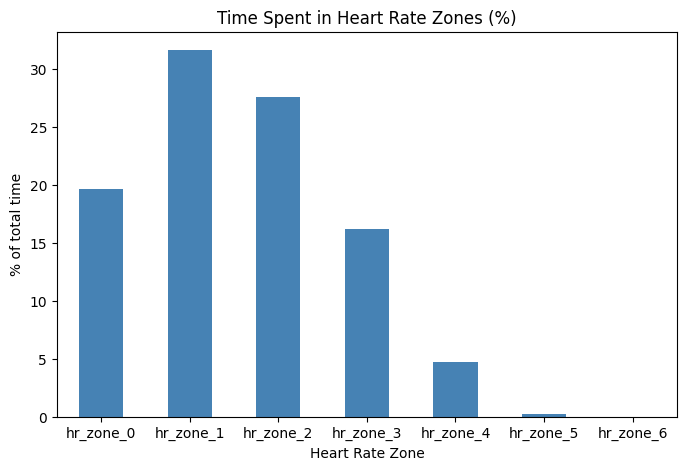

In [20]:
zone_cols = ["hr_zone_0", "hr_zone_1", "hr_zone_2", "hr_zone_3", "hr_zone_4", "hr_zone_5", "hr_zone_6"]
zone_totals = df[zone_cols].sum()   

zone_percentages = zone_totals / zone_totals.sum() * 100

zone_percentages.plot(kind="bar", title="Time Spent in Heart Rate Zones (%)", 
                       color="steelblue", figsize=(8, 5))
plt.ylabel("% of total time")
plt.xlabel("Heart Rate Zone")
plt.xticks(rotation=0)
plt.savefig("../visuals/time_in_zones.png", dpi=150, bbox_inches="tight")
plt.show()